# Algoritmos de optimización - Trabajo Práctico<br>
Nombre y Apellidos: **David Villacorta Nicolás**  <br>
GitHub: https://github.com/davidvilla10/03MIAR-Algoritmos-de-Optimizacion/tree/main/TrabajoPractico<br>
Cuaderno Google Colab: https://colab.research.google.com/drive/1R4Hz15BbyYX8U7dDnWMFIfFFek1qakMD?usp=sharing <br>
Problema:
>2. Organizar los horarios de partidos de una jornada de La Liga<br>

**Descripción del problema**:

Desde la La Liga de fútbol profesional se pretende organizar los horarios de los partidos de liga de cada jornada. Se conocen algunos datos que nos deben llevar a diseñar un algoritmo que realice la asignación de los partidos a los horarios de forma que maximice la audiencia.

Los horarios disponibles se conocen a priori y son los siguientes:

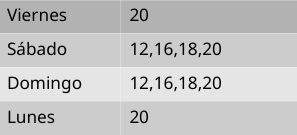


 En primer lugar se clasifican los equipos en tres categorías según el numero de seguidores (que tiene relación directa con la audiencia). Hay 3 equipos en la categoría A, 11 equipos de categoría B y 6 equipos de categoría C. Se conoce estadísticamente la audiencia que genera cada partido según los equipos
que se enfrentan y en horario de sábado a las 20h (el mejor en todos los casos).


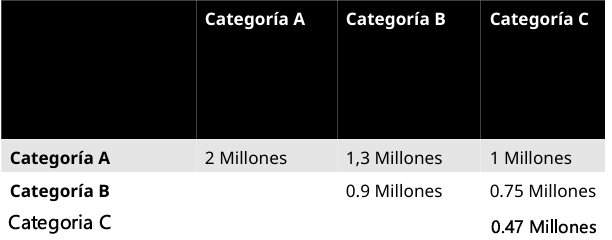

 Si el horario del partido no se realiza a las 20 horas del sábado se sabe que se reduce según los coeficientes de la siguiente tabla. Debemos asignar obligatoriamente siempre un partido el viernes y un partido el lunes

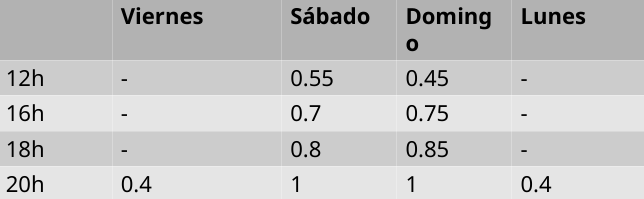

 Es posible la coincidencia de horarios pero en este
caso la audiencia de cada partido se verá afectada y
se estima que se reduce en porcentaje según la
siguiente tabla dependiendo del número de
coincidencias:   

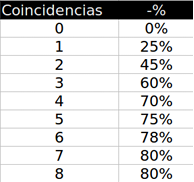


Los cálculos asociados a una jornada de ejemplo se realizan según se muestra en la siguiente tabla:

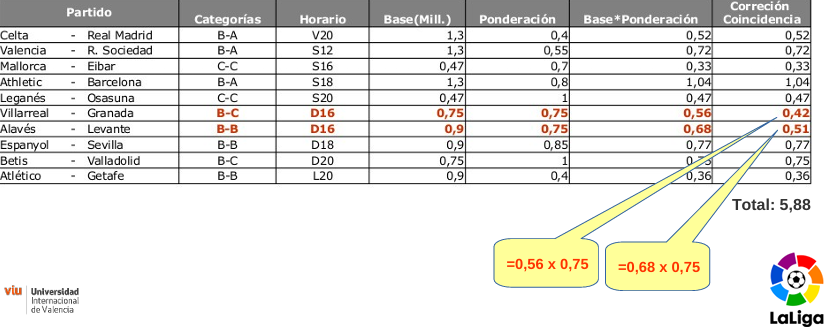

#Modelo
- ¿Como represento el espacio de soluciones?
- ¿Cual es la función objetivo?
- ¿Como implemento las restricciones?

## 1. ¿Cómo represento el espacio de soluciones?

Como los partidos ya están fijados y ordenados según la tabla del enunciado, representamos una solución como una lista $s$ de longitud 10:

$s = [h_0, h_1, ..., h_9]$

donde $h_i$ es el horario asignado al partido $i$-ésimo $(h_i \in \{V20, S12, S16, S18, S20, D12, D16, D18, D20, L20\})$.

La posición 0 corresponde al horario del partido Celta - Real Madrid, la posición 1 al del Valencia - Real Sociedad, etc.


Mi justificación para elegir esta representación es que me resulta muy cómoda a la hora de implementar el algoritmo dado que:
- Cada partido es una decisión independiente (una posición en la lista).
- Permite coincidencias (varios partidos pueden tener el mismo horario porque una lista puede tener elementos repetidos).
- Es fácil generar vecinos (cambiando el horario de un partido).


## 2. ¿Cuál es la función objetivo?

Queremos **maximizar la audiencia total generada por la jornada**.

Dada una solución $s = [h_0, h_1, ..., h_9]$, definimos la función objetivo como:

$f(s) = \sum_{i=0}^{9} A_i(s)$

donde $A_i(s)$ es la audiencia final del partido $i$ bajo la solución completa $s$. La audiencia final de cada partido, $A_i(s)$, depende de tres factores:

1. **Audiencia base** según las categorías de los equipos:
   
   $B_i$

2. **Factor del horario asignado**:
   
   $F(h_i)$

3. **Penalización por coincidencias** en la franja $h_i$:
   
   Sea $C(h_i, s)$ el número de partidos distintos que comparten la franja $h_i$ en la solución $s$. La penalización es una función $P(C(h_i, s))$, definida según la tabla del enunciado.

Por tanto:

$A_i(s) = B_i \cdot F(h_i) \cdot \big(1 - P(C(h_i, s))\big)$

Sustituyendo, obtenemos la expresión de la función objetivo en función de la solución $s$:

$f(s) = \sum_{i=0}^{9} B_i \cdot F(h_i) \cdot \big(1 - P(C(h_i, s))\big)$

Nuestro objetivo es:

$\max_{s \in \Omega_{\text{factible}}} f(s)$

donde $\Omega_{\text{factible}}$ es el conjunto de soluciones que cumplen la restricción de que exista al menos un partido en V20 y al menos uno en L20. En el apartado de Análisis estudiaremos cuántos elementos hay en ese conjunto.




## 3. ¿Cómo implemento las restricciones?

La restricción del problema es:
- Debe existir al menos un partido en **V20** y al menos un partido en **L20**.

La implementamos del siguiente modo:
- Siempre generamos soluciones factibles.
- Si al crear una solución (o un vecino) falta V20 o L20, reparamos la solución moviendo algún partido a ese slot.

Con esta estrategia de reparación garantizamos que el algoritmo opere únicamente en el espacio factible, evitando evaluar continuamente soluciones inválidas.


In [13]:
import random
import math
from collections import defaultdict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

In [14]:
# Partidos fijos de la jornada (solo asignamos horarios)
PARTIDOS = [
    ("Celta", "Real Madrid", "B", "A"),        # B-A
    ("Valencia", "Real Sociedad", "B", "A"),   # B-A
    ("Mallorca", "Eibar", "C", "C"),           # C-C
    ("Athletic", "Barcelona", "B", "A"),       # B-A
    ("Leganes", "Osasuna", "C", "C"),          # C-C
    ("Villareal", "Granada", "B", "C"),        # B-C
    ("Alaves", "Levante", "B", "B"),           # B-B
    ("Español", "Sevilla", "B", "B"),          # B-B
    ("Betis", "Valladolid", "B", "C"),         # B-C
    ("Atletico", "Getafe", "B", "B"),          # B-B
]

# Franjas horarias disponibles
FRANJAS = ["V20", "S12", "S16", "S18", "S20", "D12", "D16", "D18", "D20", "L20"]

# Factores de reducción por horario
factor_horario = {
    "V20": 0.40,
    "S12": 0.55,
    "S16": 0.70,
    "S18": 0.80,
    "S20": 1.00,
    "D12": 0.45,
    "D16": 0.75,
    "D18": 0.85,
    "D20": 1.00,
    "L20": 0.40,
}

# Audiencia base (en millones) según categorías de los equipos enfrentados
# Tabla simétrica: A-A 2.0, A-B 1.3, A-C 1.0, B-B 0.9, B-C 0.75, C-C 0.47
audiencia_base = {
    ("A", "A"): 2.00,
    ("A", "B"): 1.30,
    ("A", "C"): 1.00,
    ("B", "B"): 0.90,
    ("B", "C"): 0.75,
    ("C", "C"): 0.47,
}

def obtener_audiencia_base(cat1, cat2):
    categoria_ordenada = tuple(sorted([cat1, cat2]))
    return audiencia_base[categoria_ordenada]

# Penalización por número de coincidencias en el mismo horario
penalizacion_coincidencias = {
    0: 0.00,
    1: 0.25,
    2: 0.45,
    3: 0.60,
    4: 0.70,
    5: 0.75,
    6: 0.78,
    7: 0.80,
    8: 0.80,
}


In [15]:
def calcular_audiencia_total(solucion, devolver_detalle=False):
    """
    solucion: diccionario de la forma {indice_partido: franja}

    Devuelve la audiencia total (en millones) tras:
      - multiplicar la audiencia base por el factor del horario
      - aplicar la reducción por coincidencias en la misma franja
    """

    # Agrupamos los partidos por franja horaria
    partidos_por_franja = defaultdict(list)
    for indice_partido, franja in solucion.items():
        partidos_por_franja[franja].append(indice_partido)


    detalle_partidos = {} # detalle para mostrar por pantalla

    # Recorremos cada franja para calcular su penalización por coincidencias
    for franja, indices in partidos_por_franja.items():
        numero_partidos = len(indices)

        # Si hay n partidos en la franja, cada uno coincide con (n-1) partidos más
        coincidencias = max(0, numero_partidos - 1)

        # Limitamos el valor de coincidencias al máximo definido en el diccionario
        coincidencias_limitadas = min(coincidencias, max(penalizacion_coincidencias.keys()))

        porcentaje_reduccion = penalizacion_coincidencias[coincidencias_limitadas]
        multiplicador_final = 1.0 - porcentaje_reduccion

        # Calculamos la audiencia individual de cada partido en esta franja
        for indice_partido in indices:
            local, visitante, cat_local, cat_visitante = PARTIDOS[indice_partido]

            audiencia_base_partido = obtener_audiencia_base(cat_local, cat_visitante)
            audiencia_antes_penalizacion = audiencia_base_partido * factor_horario[franja]
            audiencia_final = audiencia_antes_penalizacion * multiplicador_final

            detalle_partidos[indice_partido] = {
                "partido": f"{local} - {visitante} ({cat_local}-{cat_visitante})",
                "franja": franja,
                "audiencia_base_M": audiencia_base_partido,
                "factor_horario": factor_horario[franja],
                "audiencia_antes_penalizacion_M": audiencia_antes_penalizacion,
                "numero_coincidencias": coincidencias,
                "porcentaje_reduccion": porcentaje_reduccion,
                "audiencia_final_M": audiencia_final,
            }

    # Sumamos la audiencia final de todos los partidos
    audiencia_total = sum(d["audiencia_final_M"] for d in detalle_partidos.values())

    # Si queremos análisis detallado, devolvemos también la tabla
    if devolver_detalle:
        df = pd.DataFrame.from_dict(detalle_partidos, orient="index")
        df.index.name = "indice_partido"
        df = df.sort_values(["franja", "audiencia_final_M"], ascending=[True, False])
        return audiencia_total, df

    return audiencia_total


def cumple_restricciones(solucion):
    """
    Comprobamos la restricción del problema:
    Debe haber al menos un partido en V20 y al menos uno en L20.
    """
    uso_franjas = defaultdict(int)

    for franja in solucion.values():
        uso_franjas[franja] += 1

    return (uso_franjas["V20"] >= 1) and (uso_franjas["L20"] >= 1)


def funcion_objetivo_penalizada(solucion, penalizacion=10_000.0):
    """
    Función objetivo penalizada.

    Si la solución incumple la restricción, restamos una penalización muy grande
    para que el algoritmo evite este tipo de soluciones.

    'penalizacion' está expresada en millones y debe ser mucho mayor que cualquier
    audiencia posible.
    """
    valor = calcular_audiencia_total(solucion)

    if not cumple_restricciones(solucion):
        return valor - penalizacion

    return valor


In [16]:
def generar_solucion_aleatoria():
    """
    Generamos una solución inicial asignando a cada partido una franja al azar.

    Importante: como tenemos una restricción (V20 y L20 no pueden quedar vacíos),
    al final siempre llamamos a la función de reparación para garantizar factibilidad.
    """
    solucion = {}
    for indice_partido in range(len(PARTIDOS)):
        solucion[indice_partido] = random.choice(FRANJAS)

    # Reparamos para cumplir que V20 y L20 tengan al menos 1 partido
    return reparar_solucion(solucion)


def reparar_solucion(solucion):
    """
    Nos aseguramos de que la solución cumpla la restricción dura:
      - Al menos un partido en V20
      - Al menos un partido en L20

    Si alguna de estas franjas está vacía, movemos un partido aleatorio a dicha franja.
    Esto es una estrategia de "reparación", útil para que el algoritmo siempre trabaje
    dentro del espacio factible (y no pierda iteraciones evaluando soluciones inválidas).
    """
    solucion = dict(solucion)

    # Contamos cuántos partidos hay en cada franja
    partidos_por_franja = defaultdict(list)
    for indice_partido, franja in solucion.items():
        partidos_por_franja[franja].append(indice_partido)

    # Si la franja V20 está vacía, forzamos un partido aleatorio a V20
    if len(partidos_por_franja["V20"]) == 0:
        indice_partido = random.randrange(len(PARTIDOS))
        solucion[indice_partido] = "V20"

    # Recalculamos porque acabamos de modificar la solución
    partidos_por_franja = defaultdict(list)
    for indice_partido, franja in solucion.items():
        partidos_por_franja[franja].append(indice_partido)

    # Si la franja L20 está vacía, forzamos un partido aleatorio a L20
    if len(partidos_por_franja["L20"]) == 0:
        indice_partido = random.randrange(len(PARTIDOS))
        solucion[indice_partido] = "L20"

    return solucion


In [17]:
def generar_vecino(solucion):
    """
    Generamos una solución vecina a partir de otra solución dada.
    """
    vecino = dict(solucion)

    # Elegimos un partido aleatorio
    indice_partido = random.randrange(len(PARTIDOS))

    franja_actual = vecino[indice_partido]

    # Elegimos una franja distinta a la actual para movernos por el espacio de soluciones
    opciones = [franja for franja in FRANJAS if franja != franja_actual]
    vecino[indice_partido] = random.choice(opciones)

    # Como tenemos una restricción (V20 y L20 no pueden quedar vacíos),
    # reparamos el vecino por si el movimiento ha dejado alguna franja obligatoria vacía.
    vecino = reparar_solucion(vecino)

    return vecino


In [18]:
def recocido_simulado(
    numero_iteraciones=50_000,
    temperatura_inicial=1.0,
    factor_enfriamiento=0.9995,
    numero_reinicios=20,
    penalizacion=10_000.0,
    verbose=False
):
    """
    Implementamos Recocido Simulado (Simulated Annealing) para MAXIMIZAR la audiencia.

    Idea general:
    - Partimos de una solución inicial aleatoria.
    - En cada iteración generamos un vecino (pequeño cambio).
    - Si el vecino mejora, lo aceptamos.
    - Si empeora, lo aceptamos a veces con probabilidad exp(delta / T),
      lo que nos ayuda a escapar de óptimos locales al principio.
    - Poco a poco bajamos la temperatura (enfriamos) y el algoritmo se vuelve más exigente.

    Parámetros:
    - temperatura_inicial: controla cuánta exploración hacemos al principio.
    - factor_enfriamiento: multiplicador de enfriamiento; cuanto más cerca de 1, más lento enfría.
    - numero_reinicios: repetimos el algoritmo varias veces desde soluciones distintas para reducir
      la probabilidad de quedarnos atrapados en un mal óptimo local.
    - penalizacion: castigo muy grande si una solución viola restricciones (por si acaso),
      aunque en nuestro caso usamos reparación y normalmente trabajamos en el espacio factible.
    """
    mejor_solucion_global = None
    mejor_audiencia_global = -float("inf")

    # Multiarranque: repetimos el proceso con distintas soluciones iniciales para explorar más zonas del espacio de soluciones
    for reinicio in range(numero_reinicios):
        solucion_actual = generar_solucion_aleatoria()
        valor_actual = funcion_objetivo_penalizada(solucion_actual, penalizacion=penalizacion)

        mejor_solucion_local = dict(solucion_actual)
        mejor_valor_local = valor_actual

        temperatura = temperatura_inicial

        for iteracion in range(numero_iteraciones):
            candidato = generar_vecino(solucion_actual)
            valor_candidato = funcion_objetivo_penalizada(candidato, penalizacion=penalizacion)

            delta = valor_candidato - valor_actual  # mejora (>0) o empeora (<0)

            # Regla de aceptación:
            # - si mejora: aceptamos siempre
            # - si empeora: aceptamos con cierta probabilidad (dependiente de la temperatura)
            if delta >= 0:
                aceptar = True
            else:
                # Cuanto más alta sea la temperatura, más probable es aceptar empeoramientos.
                # Esto nos permite explorar más y escapar de óptimos locales.
                aceptar = (random.random() < math.exp(delta / max(temperatura, 1e-12)))

            if aceptar:
                solucion_actual = candidato
                valor_actual = valor_candidato


                # Si hemos encontrado una mejor solución local, la guardamos
                if valor_actual > mejor_valor_local:
                    mejor_solucion_local = dict(solucion_actual)
                    mejor_valor_local = valor_actual

            # Enfriamiento: reducimos gradualmente la temperatura
            temperatura *= factor_enfriamiento

        # Evaluamos la mejor solución local con la función real (sin penalización)
        # (debería cumplir restricción gracias a reparación)
        audiencia_real = calcular_audiencia_total(mejor_solucion_local)

        if verbose:
            print(f"[Reinicio {reinicio+1}/{numero_reinicios}] "
                  f"mejor_audiencia={audiencia_real:.3f}M")

        # Actualizamos la mejor solución global si este reinicio ha sido mejor
        if audiencia_real > mejor_audiencia_global:
            mejor_solucion_global = mejor_solucion_local
            mejor_audiencia_global = audiencia_real

    return mejor_solucion_global, mejor_audiencia_global


In [19]:
mejor_solucion, mejor_audiencia = recocido_simulado(
    numero_iteraciones=60000,
    temperatura_inicial=1.0,
    factor_enfriamiento=0.9996,
    numero_reinicios=25,
    verbose=True
)

mejor_audiencia


[Reinicio 1/25] mejor_audiencia=6.777M
[Reinicio 2/25] mejor_audiencia=6.791M
[Reinicio 3/25] mejor_audiencia=6.794M
[Reinicio 4/25] mejor_audiencia=6.833M
[Reinicio 5/25] mejor_audiencia=6.842M
[Reinicio 6/25] mejor_audiencia=6.856M
[Reinicio 7/25] mejor_audiencia=6.856M
[Reinicio 8/25] mejor_audiencia=6.755M
[Reinicio 9/25] mejor_audiencia=6.816M
[Reinicio 10/25] mejor_audiencia=6.856M
[Reinicio 11/25] mejor_audiencia=6.804M
[Reinicio 12/25] mejor_audiencia=6.856M
[Reinicio 13/25] mejor_audiencia=6.856M
[Reinicio 14/25] mejor_audiencia=6.796M
[Reinicio 15/25] mejor_audiencia=6.856M
[Reinicio 16/25] mejor_audiencia=6.842M
[Reinicio 17/25] mejor_audiencia=6.796M
[Reinicio 18/25] mejor_audiencia=6.816M
[Reinicio 19/25] mejor_audiencia=6.842M
[Reinicio 20/25] mejor_audiencia=6.819M
[Reinicio 21/25] mejor_audiencia=6.856M
[Reinicio 22/25] mejor_audiencia=6.802M
[Reinicio 23/25] mejor_audiencia=6.856M
[Reinicio 24/25] mejor_audiencia=6.822M
[Reinicio 25/25] mejor_audiencia=6.856M


6.856

In [20]:
audiencia_total, tabla_detalle = calcular_audiencia_total(mejor_solucion, devolver_detalle=True)

print(f"Audiencia total final: {audiencia_total:.3f} millones")
display(tabla_detalle)


Audiencia total final: 6.856 millones


,partido,franja,audiencia_base_M,factor_horario,audiencia_antes_penalizacion_M,numero_coincidencias,porcentaje_reduccion,audiencia_final_M
indice_partido,,,,,,,,
5,Villareal - Granada (B-C),D12,0.75,0.45,0.3375,0,0.0,0.3375
6,Alaves - Levante (B-B),D16,0.90,0.75,0.6750,0,0.0,0.6750
1,Valencia - Real Sociedad (B-A),D18,1.30,0.85,1.1050,0,0.0,1.1050
0,Celta - Real Madrid (B-A),D20,1.30,1.00,1.3000,0,0.0,1.3000
2,Mallorca - Eibar (C-C),L20,0.47,0.40,0.1880,0,0.0,0.1880
8,Betis - Valladolid (B-C),S12,0.75,0.55,0.4125,0,0.0,0.4125
9,Atletico - Getafe (B-B),S16,0.90,0.70,0.6300,0,0.0,0.6300
7,Español - Sevilla (B-B),S18,0.90,0.80,0.7200,0,0.0,0.7200
3,Athletic - Barcelona (B-A),S20,1.30,1.00,1.3000,0,0.0,1.3000


#Análisis
- ¿Que complejidad tiene el problema?. Orden de complejidad y Contabilizar el espacio de soluciones

## 1. Tamaño del espacio de soluciones
Definimos:

- $n$ = número de partidos
- $m$ = número de franjas horarias disponibles

Cada uno de los $n$ partidos puede asignarse a cualquiera de las $m$ franjas horarias. Como se permiten coincidencias, las decisiones son independientes, por lo que el número total de soluciones es:

$|\Omega| = m^n$

En nuestro caso concreto:

$|\Omega| = 10^{10}$

Si imponemos la restricción de que V20 y L20 no pueden quedar vacíos, obtenemos el número de soluciones factibles:

- Soluciones totales: $m^n$
- Soluciones sin V20: $(m-1)^n$
- Soluciones sin L20: $(m-1)^n$
- Soluciones sin V20 ni L20: $(m-2)^n$

Por tanto, el número exacto de soluciones factibles es:

$|\Omega_{\text{factible}}| = m^n - 2(m-1)^n + (m-2)^n$

En nuestro caso:

$|\Omega_{\text{factible}}| = 10^{10} - 2\cdot 9^{10} + 8^{10}$

Esto demuestra que el espacio de búsqueda crece exponencialmente con $n$.



## 2. Orden de complejidad

### Complejidad de evaluar una solución

Para evaluar una solución $s$ (función `calcular_audiencia_total`) realizamos:

1. Un recorrido sobre los $n$ partidos para agruparlos por franja:

- Bucle `for indice_partido, franja in solucion.items():`$\Rightarrow O(n)$

2. Un recorrido por las franjas utilizadas (a lo sumo $m$) y, dentro, por los partidos asignados a cada franja:

- Bucle `for franja, indices in partidos_por_franja.items():` $\Rightarrow O(m)$

- Bucle interno `for indice_partido in indices: `  
  Si sumamos el tamaño de `indices` en todas las franjas, cada partido aparece exactamente una vez, luego:

$\sum_{\text{franja}} |\text{indices}(\text{franja})| = n \Rightarrow O(n)$

Por tanto, el coste total de evaluar una solución es:

$T_{\text{eval}}(n,m) = O(n + m)$


### Complejidad del algoritmo implementado (Recocido Simulado)

Definimos:

- $R$ = número de reinicios (multiarranque)
- $I$ = número de iteraciones por reinicio
- $n$ = número de partidos
- $m$ = número de franjas

En cada iteración del algoritmo realizamos:

1. **Generación de vecino** (`generar_vecino`):
   - Elegimos un partido aleatorio: $O(1)$
   - Construimos la lista de opciones recorriendo las $m$ franjas: `opciones = [franja for franja in FRANJAS]` $\Rightarrow O(m)$
   - Reparación (`reparar_solucion`): recorre la lista de partidos $\Rightarrow O(n)$

   Por tanto:

$T_{\text{vecino}}(n,m) = O(n + m)$

2. **Evaluación del vecino** (`calcular_audiencia_total`):

$T_{\text{eval}}(n,m) = O(n + m)$

Luego, el coste por iteración está dominado por:

$T_{\text{iter}}(n,m) = O(n + m)$

El coste por reinicio es:

$T_{\text{reinicio}}(n,m) = I \cdot O(n + m)$

Y el coste total del algoritmo es:

$T_{\text{SA}}(n,m) = R \cdot I \cdot O(n + m) = O(R \cdot I \cdot (n+m))$







#Diseño
- ¿Que técnica utilizo? ¿Por qué?

### 1. Técnica elegida: Recocido Simulado (Simulated Annealing)

Para resolver este problema he elegido **Recocido Simulado (SA)**, una de las metaheurísticas vistas en clase, inspirada en el proceso físico de enfriamiento de materiales. La idea clave es recorrer el espacio de soluciones mediante pequeños cambios (vecinos), aceptando siempre las mejoras y aceptando a veces empeoramientos con una probabilidad controlada por una temperatura $T$. De este modo conseguimos combinar:

- **Exploración (diversificación)** al principio: el algoritmo permite probar regiones distintas del espacio.
- **Explotación (intensificación)** al final: cuando $T$ es baja, el algoritmo se vuelve más exigente y se centra en refinar.

Esta combinación es especialmente adecuada para nuestro problema, ya que el espacio de búsqueda es enorme y la función objetivo tiene interacciones entre decisiones.


### 2. ¿Por qué Recocido Simulado?

Hay diversos factores que me hicieron considerar que este algoritmo encaja bien con este problema.

#### 2.1) Espacio de búsqueda exponencial y necesidad de metaheurística
Tenemos un problema de asignación discreta: para $n$ partidos y $m$ franjas, el espacio de soluciones crece como $m^n$. En nuestro caso, incluso con $n=10$ y $m=10$, ya aparecen $10^{10}$ combinaciones. Esto hace inviable una búsqueda exacta.  
Por tanto, necesitamos una técnica **aproximada/heurística** que explore solo una parte del espacio pero sea capaz de encontrar soluciones de alta calidad.

#### 2.2) Función objetivo no separable por las interacciones
La audiencia de un partido no depende únicamente del horario elegido para ese partido, sino también de cuántos partidos coinciden en la misma franja (penalización por coincidencia). Esto introduce dependencia entre variables: mover un partido puede alterar la audiencia de varios partidos a la vez. Este tipo de función objetivo genera un espacio con muchos óptimos locales, donde una búsqueda local voraz podría quedarse atascada rápidamente. Recocido Simulado está diseñado precisamente para estos casos: permite salir de óptimos locales aceptando empeoramientos de forma controlada al inicio.


#### 2.3) Restricciones fáciles de integrar de forma robusta
La restricción del enunciado es que debe existir al menos un partido en V20 y al menos uno en L20. Para garantizar que el algoritmo se mantenga en el espacio factible hemos implementado una estrategia de reparación: si una solución (o vecino) deja vacía una franja obligatoria, movemos automáticamente algún partido a ese slot. Esto evita perder tiempo evaluando soluciones inválidas y hace el proceso más estable.


### 3. ¿Cómo hemos implementado Recocido Simulado?

#### 3.1) Solución inicial
Comenzamos desde una solución aleatoria (asignando a cada partido una franja al azar) y la reparamos para cumplir V20 y L20.

#### 3.2) Generación de vecinos
En cada iteración generamos un vecino cambiando la franja de un partido aleatorio a otra franja distinta. Tras el cambio, reparamos si fuese necesario.

#### 3.3) Regla de aceptación
Sea $\Delta = f(\text{vecino}) - f(\text{actual})$, donde $f$ es la audiencia total.

- Si $\Delta \ge 0$, aceptamos el vecino (mejora).
- Si $\Delta < 0$, aceptamos con probabilidad:

$P(\text{aceptar}) = e^{\Delta / T}$

Esto significa que cuando $T$ es alta, aún aceptamos algunos empeoramientos (exploración). Cuando $T$ baja, esa probabilidad cae y el algoritmo se vuelve más conservador (explotación).

#### 3.4) Enfriamiento
Usamos enfriamiento multiplicativo:

$T \leftarrow \alpha T$

con $\alpha$ cercano a 1. Esto nos da un descenso gradual de la temperatura, permitiendo explorar bien al inicio y refinar al final.


#### 3.5) Reinicios (multiarranque)

Aunque SA puede escapar de óptimos locales, sigue siendo un algoritmo estocástico: el resultado depende de la solución inicial y de decisiones aleatorias durante la búsqueda.

Para aumentar la robustez implementamos multiarranque (reinicios):

- Ejecutamos el recocido simulado $R$ veces desde soluciones iniciales distintas.
- Nos quedamos con la mejor solución encontrada globalmente.

Esto reduce la probabilidad de quedarnos atrapados en una región mala del espacio y suele mejorar la calidad final sin complicar el diseño. En problemas combinatorios como este, el multiarranque es una mejora muy efectiva dado que si el espacio es grande y el algoritmo es probabilista (como es el caso), repetirlo desde distintos puntos aumenta la cobertura del espacio explorado.
